In [1]:
import os
import torch
import torchvision
import matplotlib.pyplot as plt

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)

PyTorch version: 2.11.0+cpu
Torchvision version: 0.26.0+cpu


In [2]:
DATASET_PATH = r"C:\Users\Admin\OneDrive\Desktop\Visual_Defect_Detection\archive\NEU-DET"

TRAIN_PATH = os.path.join(DATASET_PATH, "train", "images")
VAL_PATH = os.path.join(DATASET_PATH, "validation", "images")

print("Train path:", TRAIN_PATH)
print("Validation path:", VAL_PATH)

Train path: C:\Users\Admin\OneDrive\Desktop\Visual_Defect_Detection\archive\NEU-DET\train\images
Validation path: C:\Users\Admin\OneDrive\Desktop\Visual_Defect_Detection\archive\NEU-DET\validation\images


In [3]:
print("Train folder exists:", os.path.exists(TRAIN_PATH))
print("Validation folder exists:", os.path.exists(VAL_PATH))

Train folder exists: True
Validation folder exists: True


In [4]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    
    transforms.ToTensor(),
    
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Training transformations created.")

Training transformations created.


In [5]:
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    
    transforms.ToTensor(),
    
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Validation transformations created.")

Validation transformations created.


In [6]:
train_dataset = ImageFolder(
    root=TRAIN_PATH,
    transform=train_transform
)

val_dataset = ImageFolder(
    root=VAL_PATH,
    transform=val_transform
)

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))

Training images: 1440
Validation images: 360


In [7]:
print("Class names:")
print(train_dataset.classes)

print("\nClass to index mapping:")
print(train_dataset.class_to_idx)

Class names:
['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']

Class to index mapping:
{'crazing': 0, 'inclusion': 1, 'patches': 2, 'pitted_surface': 3, 'rolled-in_scale': 4, 'scratches': 5}


In [8]:
image, label = train_dataset[0]

print("Tensor shape:", image.shape)
print("Label:", label)
print("Class:", train_dataset.classes[label])

Tensor shape: torch.Size([3, 224, 224])
Label: 0
Class: crazing


In [9]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("DataLoaders created.")

DataLoaders created.


In [10]:
images, labels = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)

Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])


In [11]:
def show_images(images, labels, class_names):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    images = images * std + mean
    images = torch.clamp(images, 0, 1)

    plt.figure(figsize=(12, 8))

    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].permute(1, 2, 0))
        plt.title(class_names[labels[i]])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

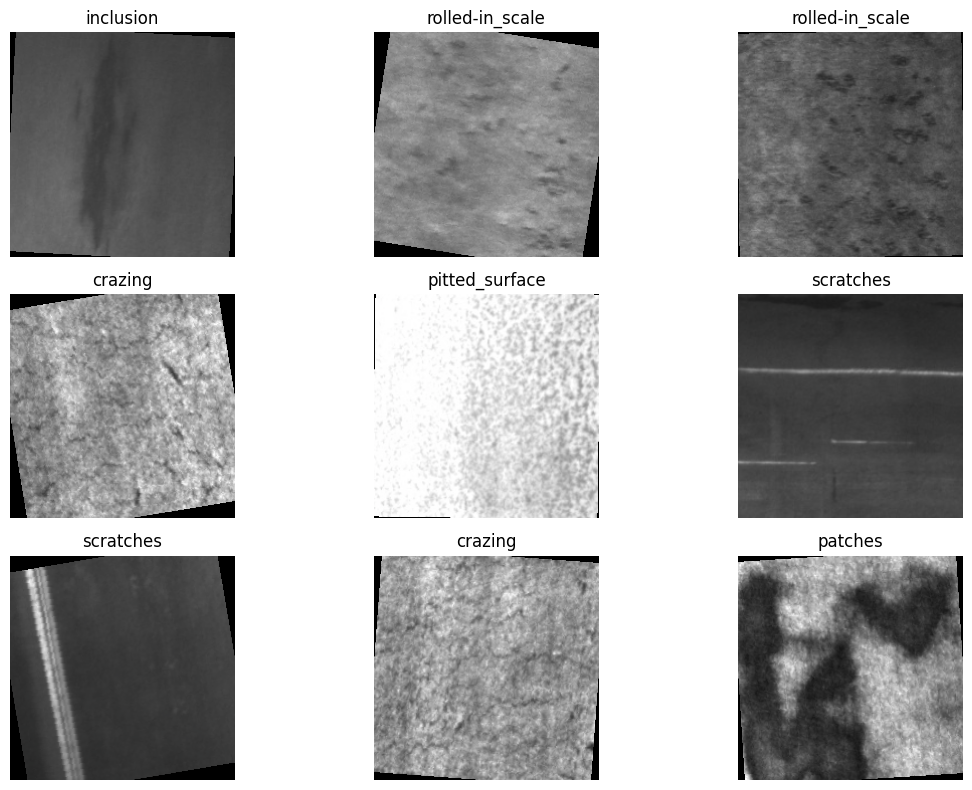

In [12]:
show_images(images, labels, train_dataset.classes)

In [13]:
val_images, val_labels = next(iter(val_loader))

print("Validation batch image shape:", val_images.shape)
print("Validation batch label shape:", val_labels.shape)

Validation batch image shape: torch.Size([32, 3, 224, 224])
Validation batch label shape: torch.Size([32])


In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("CUDA GPU not available. Training will use CPU.")

Device: cpu
CUDA GPU not available. Training will use CPU.
